## Customer Churn Analysis 

### Calculation Metrics
| KPI | Formula |
| :--- | :--- |
| **Churn Rate** | `churned customer / total customers` |
| **Churn by Plan Type** | `churn rate GROUP BY plan_type (Basic/Standard/Premium)` |
| **Churn by State** | `churn rate GROUP BY country, state` |
| **Retention Rate** | `1 - churn rate` |
| **ARPU** | `SUM(monthly_charges) / COUNT(active customerid)` |
| **Average Customer Tenure** | `AVG(DATEDIFF(cancellation_date OR NOW(), subscription_start_date))` |
| **Revenue at Risk** | `SUM(monthly_charges) WHERE churn_score > 70` |
| **Escalation Rate** | `(SUM(escalations) / COUNT(complaints)) × 100` |
| **Avg Complaints per Customer** | `COUNT(complaints) / COUNT(DISTINCT customerid)` |
| **Correlation: Escalations → Churn** | `churn rate WHERE escalations ≥ 1 vs 0` |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [2]:
# Inporting database

conn  = sqlite3.connect('customer_churn.db')

sql_query = """

SELECT name FROM sqlite_master WHERE type = 'table'

"""

tables = pd.read_sql(sql_query, conn)


# Creste dataframe for each table

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created datafroame: df_{table_name}")
    

conn.close()

Created datafroame: df_db_customer
Created datafroame: df_db_subscription
Created datafroame: df_db_support


In [4]:
# printing table names and columns

conn = sqlite3.connect('customer_churn.db')


for table_name in tables['name']:
    print(f"\n Table Name: {table_name}")
    # GET column informations
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("columns: ")
    print(columns['name'].tolist())
    
conn.close()


 Table Name: db_customer
columns: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

 Table Name: db_subscription
columns: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

 Table Name: db_support
columns: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# Data Cleaning

In [5]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [8]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [ ]:
# 1. rename column name for make it more understanable
# 2. drop columns inetrest and pincode 
# 3. change datatype dob
# 4. data standardization of gender column
# 5. Fix missing values from the table

In [11]:
# 1. rename column - name

df_db_customer.rename(columns = {'name': 'customer_name'}, inplace=True )

df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [14]:
#2. drop columns - interest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
df_db_customer.drop(columns= ['interests', 'pincode'], inplace=True)

In [17]:
# 3. change datatype dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [20]:
# 4. data standardization of gender column
df_db_customer['gender'].unique()

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'})

In [21]:
# 5. Fix missing values from the table
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [26]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))



In [27]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [29]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [30]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [31]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,None,None,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,None,None,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,None,None,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,None,None,13.99,790,47


In [32]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [34]:
df_db_subscription['renewal_date'] = pd.to_datetime(df_db_subscription['renewal_date'])
df_db_subscription['subscription_start_date'] = pd.to_datetime(df_db_subscription['subscription_start_date'])
df_db_subscription['cancellation_date'] = pd.to_datetime(df_db_subscription['cancellation_date'])

In [35]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [36]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [37]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 560.0+ bytes


In [38]:
df_db_support.drop(columns=['col_1','comment'], inplace=True)

In [39]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

# Feature Engineering and Data Analysis

In [ ]:
# Create a new column using existing column - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [42]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [ ]:
# found flaw on data so fix it and then merge again
df = (df_db_subscription
                .merge(df_db_customer, on='customerid', how='left')
                .merge(df_db_support, on='customerid', how='left'))

In [46]:
df_db_subscription.shape


(21, 12)

In [ ]:
#some values are repetaing there should be 21 rows
df.shape

(23, 20)

In [49]:
df_db_subscription['customerid'].nunique()

21

In [50]:
df_db_customer['customerid'].nunique()

21

In [60]:
df_db_support['customerid'].nunique()

7

In [59]:
df_db_support['customerid'].size

7

In [54]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [56]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [58]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [62]:
df = (df_db_subscription
                .merge(df_db_customer, on='customerid', how='left')
                .merge(df_db_support, on='customerid', how='left'))

In [64]:
df.shape

(21, 21)

In [65]:
df.to_csv('exported_churn_data.csv', index=False)

# Data Analysis

In [66]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [ ]:
# 1. Churn Rate

churn_rate = df['churn_flag'].mean() * 100
print("Churn Rate  = ", round(churn_rate, 2), "%")

Churn Rate  =  28.57 %


In [71]:
# 2. Retention Rate

retention_rate = 100 - churn_rate;
print("Retention Rate  = ", round(retention_rate, 2), "%")

Retention Rate  =  71.43 %


In [73]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [ ]:
# 3. Churn by plan type

churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'Churn_rate_pct')
print(churn_by_plan)

  plan_type  Churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [ ]:
# 4. Churn by state + sum(revenue) and count of users

In [82]:
# 5. ARPU - Average revenue per user
arpu = df['monthly_charges'].mean()
print("ARPU: ", round(arpu, 2))

ARPU:  18.85


In [90]:
# 6. Average tenure
# use current date if user hasnt cancelled the subscription yet or else use the cancelled date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(), (df['cancellation_date']- df['subscription_start_date']).dt.days, (today-df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()

print("Average Tenure (Days) = ", round(avg_tenure, 2))

Average Tenure (Days) =  1517.29


In [92]:
# 7. Revenue at risk - revenue lost form churned customers

rev_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()

print("Revenue at risk: ", rev_at_risk)

Revenue at risk:  73.94


In [102]:
# 8. Esclation rate

esc_rate = (df['escalations'] == 'Y').mean()

print("Escalation Rate: ", round(esc_rate, 2))

Escalation Rate:  0.19


In [108]:
#9. Avg Complaint Rate

avg_complains = df['complaint_count'].sum() / df['customerid'].nunique()

print("Average complains", round(avg_complains, 2))

Average complains 0.43


In [ ]:
# 10. Correlation Esclation vs Churn

#df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type

corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])

print("Correlation between escalation and churn is: ", correlation)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3898375575.py, line 9)

In [114]:
# 11. Churn risk - create a column using existing column

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')

# Data visulization

In [118]:
df_visual = df.copy()

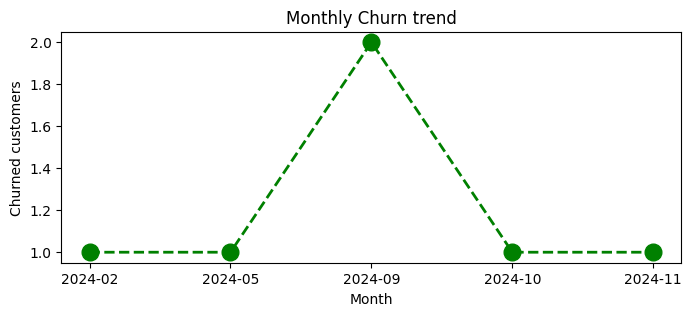

In [121]:
# Monthly churn trend (time serise KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype('str'), churn_trend.values, color = 'green', marker = 'o', linestyle = 'dashed', linewidth = 2, markersize=12)
plt.title("Monthly Churn trend")
plt.xlabel("Month")
plt.ylabel('Churned customers')
plt.show()

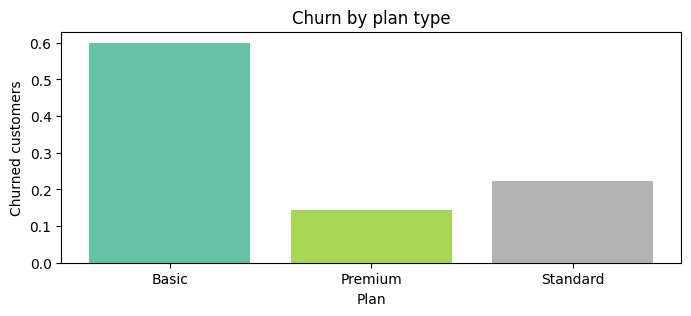

In [128]:
# Churn by plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(8,3))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.title("Churn by plan type")
plt.xlabel("Plan")
plt.ylabel('Churned customers')
plt.show()

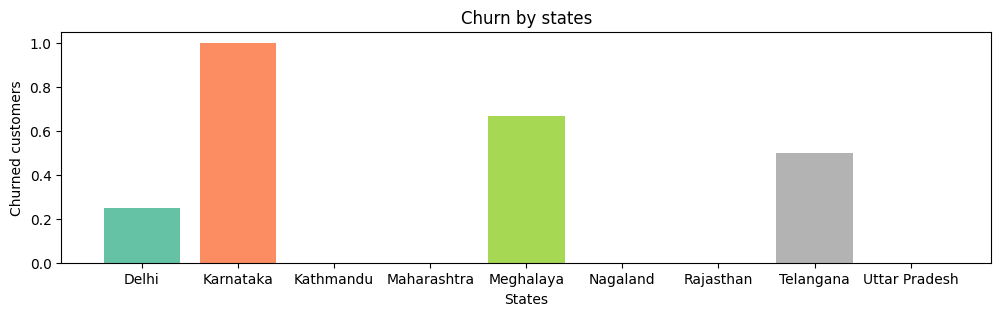

In [131]:
# churn by states

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(12,3))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.title("Churn by states")
plt.xlabel("States")
plt.ylabel('Churned customers')
plt.show()

In [132]:
# encodeing - convert str to numeric
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [133]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [ ]:
#incorrect method of encodeing

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

categorical_columns = ['plan_type', 'contract_type', 'churn_risk']

for col in categorical_columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [135]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

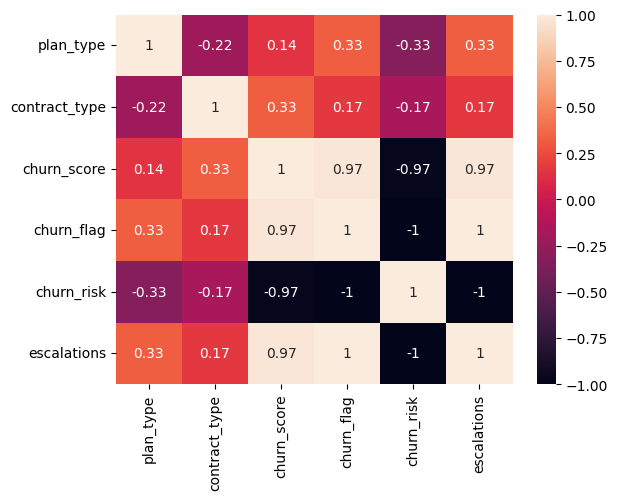

In [136]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot= True)

In [ ]:

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {'plan_type': ['Basic', 'Standard', 'Premium'],
                       'contract_type': ['Monthly', 'Annual'],
                       'churn_risk': ['low', 'med', 'high']}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [142]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

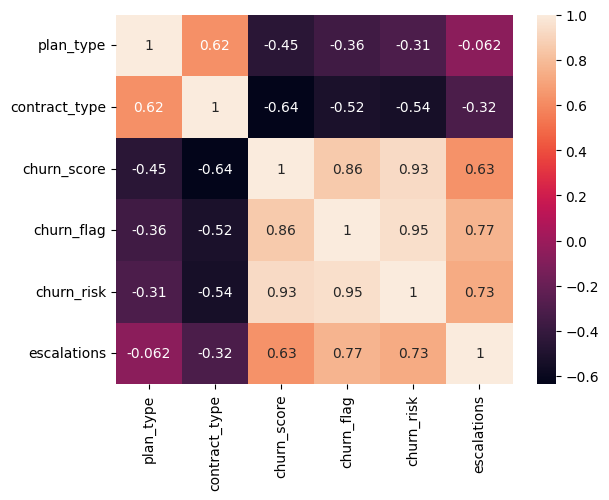

In [143]:
sns.heatmap(df_encoded.corr(), annot= True)

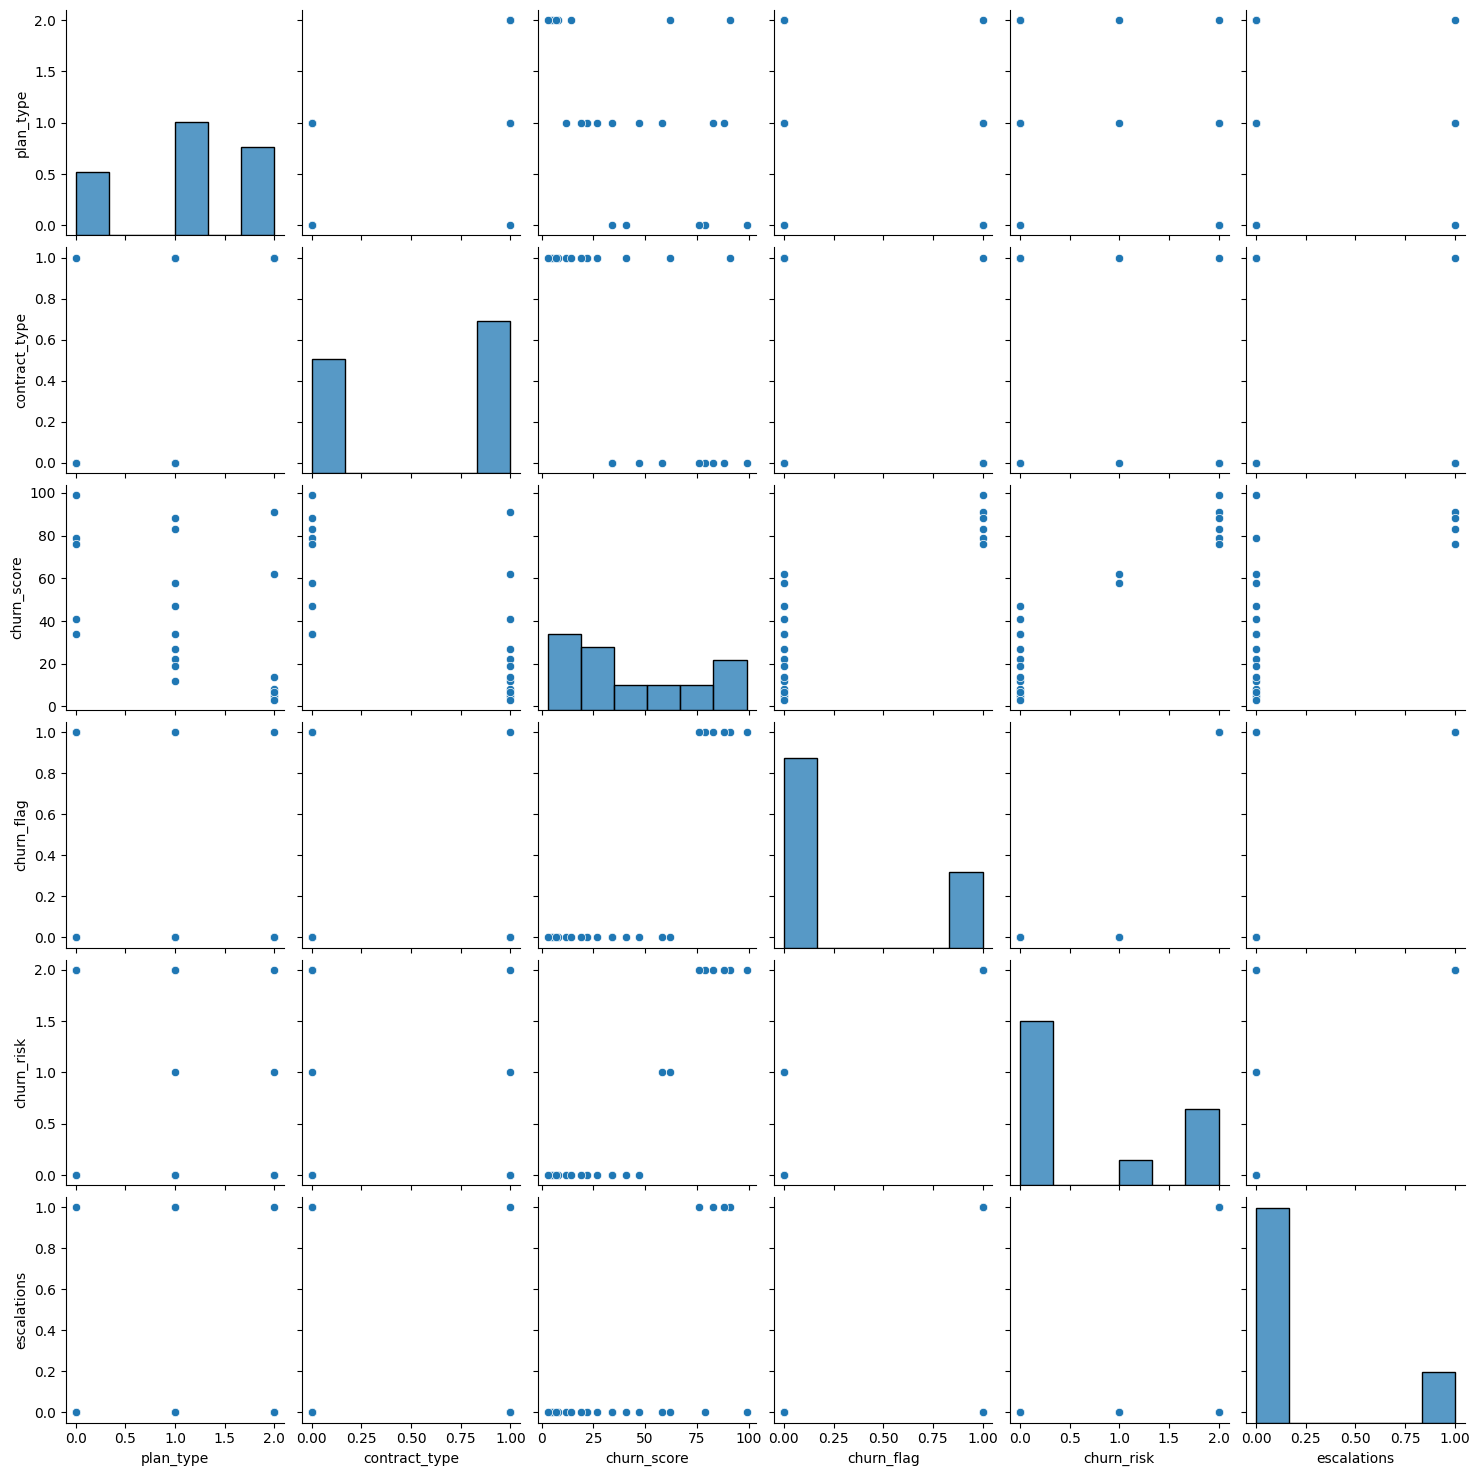

In [144]:
# Pairplot

sns.pairplot(df_encoded)

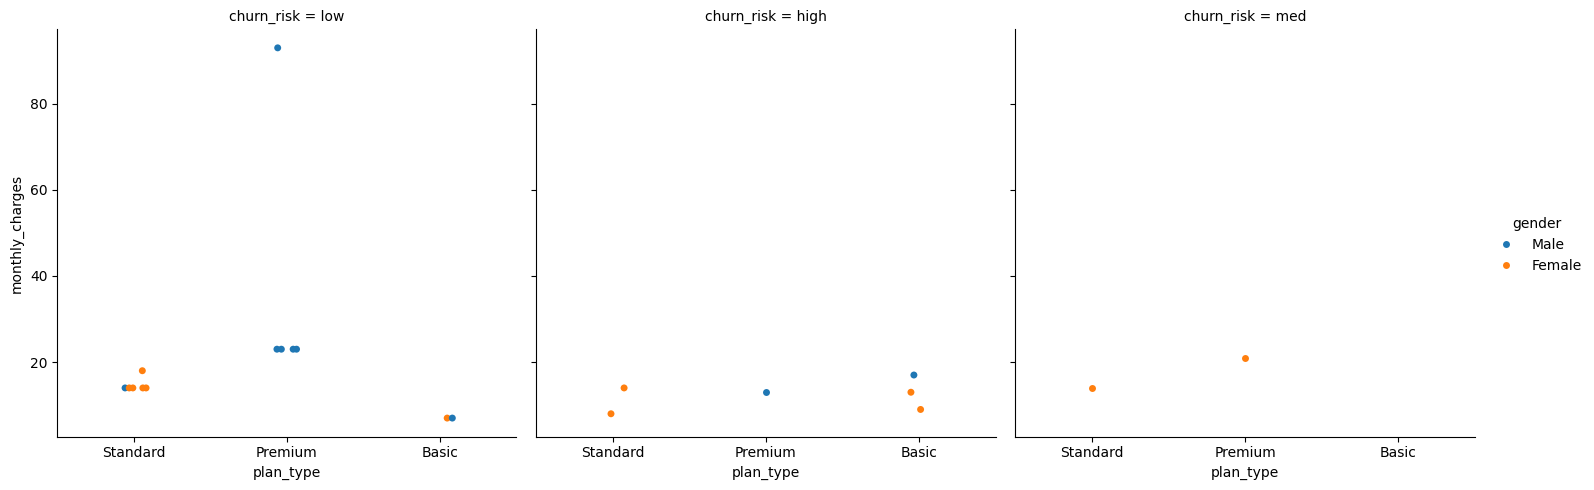

In [146]:
# Cateplot/ Facegrid - multi-dim comparision

sns.catplot(data= df_visual,
            x = 'plan_type',
            y= 'monthly_charges',
            hue = 'gender',
            col = 'churn_risk')

# Pivot table

In [148]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [151]:
pd.pivot_table(
    df_visual,
    values = ['churn_flag', 'customerid', 'monthly_charges'],
    index = 'plan_type',
    aggfunc = {
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn_flag': 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
